# PWM And Breathe Effects

Some notes to put my thoughts in order.

I'm trying to display an LED effect but instead of timings, I will use the interrupts generated by the PWM wave itself to drive the timings.

## Some definitions, I guess

I'm using one of the timers on the EFR32BG22 (TIMER0). It has three output/compare channels, which is perfect to drive the three LED channels in the HW. Single-slope pwm is more than enough. I could switch to dual-slope, wich halves the PWM frequency (not an issue, as we are not anywhere near the limit) and reduces harmonics and has better EMI, but then again, we are using a low PWM freq.

This graph shows how the timer generates the PWM signal (section 19.3.3.9 of the manual)

![PWM Graph](img/PWMGraph.png)

A "cycle accurate" version is shown below. The timer counts from 0 up to TOP. When the count transitions from 0 to 1, the output is set to 1. When the count matches OC (output compare), the output is toggled. Finally, when we the count reaches TOP, the counter is reset to 0.

The overflow interrupt (triggered by the counter reaching TOP), is triggered in the next cycle after reaching TOP (so NOT when the count reaches TOP NOR when the count resets to 0, but on the next transition from 0 to 1). That's a bit counterintuitive, but whatever...

Similarly, the buffered updates of TOP and OC are triggered when the count switches from 0 to 1

Another side-effect, I guess, is that the period of the signal is TOP + 1 cycles, not TOP, and setting OC to TOP would toggle the output for one clock cycle (so duty cycle would be TOP / (TOP + 1) = 99.99% and not 100%). In order to get a DC of 100%, you have to set OC >= TOP + 1, so there's never a compare match.

And finally, if we update a buffered register during the overflow interrupt, changes will not affect the next PWM period, because the buffered update is triggered before (or at the same time) than the interrupt, so if you have set the OC to A and update to B in the overflow interrupt, then you have to go through an extra PWM period with OC at A, and when the timer hits TOP again, it will update the OC register.

![alt text](img/PWMCycleAccurate.png)

### Brightness Gamma Correction

Because brightness is not perceived linearly by the eye, we can apply gamma correction to get a response closer to the perceived one.

### Frequencies

The timer clock is 38.4 MHz. The PWM frequency is dictated by the TOP value. 

$$f_{pwm} = \frac{f_{clock}}{Preescaler * TOP + 1}$$

To play effects, we will use a lookup table. As long as we don't need to dynamically change it, we can precalculate it and store it in flash, and even if we have to use a dynamic table, it's 100s of B of RAM, so not a big deal, really.

Because it's the PWM wave driving the timing (to change brightness only at the rollover of the counter, using the buffered register), we will play each sample an integer number of times. if $T_{effect}$ is the period of the effect (time it takes to play all the samples of the LUT), then $T_{effect}$ must be divisible by $T_{pwm}$, or in other words, the period of the effect must always increments of $T_{pwm} * n_{samples}$ for everythin to stay in order.

$$T_{effect} = n_{samples} * T_{pwm} * n, where n > 0$$

$T_{effect}$ must increment in multiples of $n_{samples} * T_{pwm}$. For example, for a LUT of 200 samples and a PWM frequency of 1KHz, $T_{effect}$ would increase in 200ms increments.

### Interpolation

Because we have 32 bit registers and we are using one of the main timers of the chip (that is, driven by the High Freq clock), we can have a stupid level of resolution.

If we drive the PWM at 1kHz, the TOP value is 38400 (37399, really). So, while having enough samples of the effect in the LUT is enough to play it smoothly with very small increments of brightness, because we are going to have a bunch of pwm waves per sample, we can interpolate linearly their duty cycle and have them slowly increment from their intended value to the next one. Again, we have stupid resolution, let's use it.

{0, 1, 5, 12, 23, 39, 59, 85, 115, 151, 192, 240, 293, 352, 417, 489, 567, 652, 744, 842, 948, 1060, 1180, 1307, 1441, 1583, 1733, 1890, 2055, 2228, 2408, 2597, 2794, 2998, 3212, 3433, 3663, 3901, 4148, 4403, 4667, 4940, 5221, 5512, 5811, 6119, 6437, 6763, 7099, 7443, 7797, 8161, 8534, 8916, 9307, 9709, 10119, 10540, 10970, 11410, 11860, 12319, 12789, 13268, 13757, 14257, 14766, 15286, 15816, 16356, 16906, 17467, 18038, 18619, 19211, 19813, 20426, 21050, 21684, 22329, 22984, 23650, 24327, 25015, 25714, 26423, 27144, 27875, 28617, 29371, 30135, 30911, 31698, 32496, 33305, 34126, 34958, 35801, 36656, 37522, 38399}


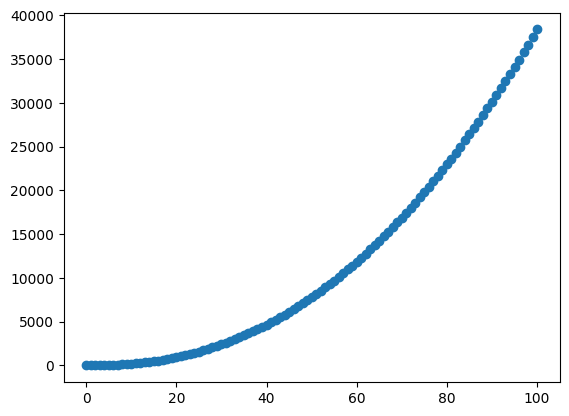

In [43]:
# From HackADay - https://hackaday.com/2016/08/23/rgb-leds-how-to-master-gamma-and-hue-for-perfect-brightness/
## Creates a gamma-corrected lookup table
import math

GAMMA = 2.3
STEPS = 101
MAXBRIGHTNESS = 38399


def gamma(nsteps: int, gamma: float) -> list[float]:
    """Returns a list with a gamma-corrected curve of nsteps steps with values from 0 to 1.

    Args:
        nsteps (_type_): size of the list to return
        gamma (_type_): gamma coefficient

    Returns:
        list[float]: list of gamma corrected values from 0 to 1
    """
    gammaedUp = [math.pow(x, gamma) for x in range(nsteps)]
    return [x / max(gammaedUp) for x in gammaedUp]  # normalize from 0 to 1


def rounder(topValue: int, gammas: list[float]) -> list[int]:
    """Returns a rounded list of values mapped from 0 to topValue using the gamma-corrected curve passed as gammas

    Args:
        topValue (int): the value to map the max value of the gamma-curve
        gammas (list[float]): a normalized (0 to 1) list of values

    Returns:
        list[int]: a list of ints, with a curve from 0 to topValue, that will be gamma-corrected
    """
    return [min(topValue, round(x * topValue)) for x in gammas]


def buildGammaLUT(nsteps: int, gamma: float, maxBrightness: int) -> list[int]:
    """Builds the gamma-corrected birghtness lookup table

    Args:
        nsteps (int): size of the lookup table
        gamma (float): the gamma correction factor
        maxBrightness (int): max brightness of the table

    Returns:
        list[int]: a list with a gamma-corrected curve
    """
    LUT: list[int] = [0] * nsteps

    for i in range(nsteps):
        aux = math.pow(i, gamma) / math.pow((nsteps - 1), gamma)
        LUT[i] = min(maxBrightness, round(aux * maxBrightness))
    return LUT


lut2 = buildGammaLUT(STEPS, GAMMA, MAXBRIGHTNESS)

# Print as C array
print("{", end="")
for i in lut2[:-1]:
    print(f"{round(i, 0):.0f}", end=", ")
print(f"{round(lut2[-1], 0):.0f}}}")

plt.scatter(range(STEPS), lut2)

## Gaussian Breathe Effect

This dude did quite a bit of research about different waves to play the breathe effect (https://makersportal.com/blog/2020/3/27/simple-breathing-led-in-arduino) and I like how the gaussian one "favours dark" as they put it, as my particular use case is to use as a mood light, and hence I don't want it to be bright. It is also very configurable, where you can tweak the shape of the wave with one parameter

![alt text](img/GaussianBreatheGamma.png)

So, the formula for the brightness is

$$B_i = B_{min} + (B_{max} - B_{min}) * e^{-\frac{((i/n_{samples})-\beta)^2}{2\gamma^2}}$$

where $B_{max}$ and $B_{min}$ is the max brightness level, $\beta$ is the relative position of the peak (from 0 to 1) and $\gamma\$ is the width parameter of the peak (lower values have a narrower peak). $i$ would be the current sample and $n_{samples}$ is the size of the LUT

[10.00, 10.00, 10.00, 10.00, 11.00, 11.00, 11.00, 11.00, 11.00, 11.00, 11.00, 11.00, 11.00, 11.00, 11.00, 12.00, 12.00, 12.00, 12.00, 12.00, 13.00, 13.00, 13.00, 13.00, 14.00, 14.00, 14.00, 15.00, 15.00, 15.00, 16.00, 16.00, 17.00, 17.00, 18.00, 19.00, 19.00, 20.00, 21.00, 21.00, 22.00, 23.00, 24.00, 25.00, 26.00, 27.00, 28.00, 29.00, 30.00, 31.00, 32.00, 34.00, 35.00, 36.00, 38.00, 39.00, 41.00, 42.00, 44.00, 45.00, 47.00, 49.00, 50.00, 52.00, 54.00, 56.00, 57.00, 59.00, 61.00, 63.00, 65.00, 66.00, 68.00, 70.00, 72.00, 74.00, 75.00, 77.00, 79.00, 80.00, 82.00, 84.00, 85.00, 87.00, 88.00, 89.00, 91.00, 92.00, 93.00, 94.00, 95.00, 96.00, 97.00, 98.00, 98.00, 99.00, 99.00, 100.00, 100.00, 100.00, 100.00, 100.00, 100.00, 100.00, 99.00, 99.00, 98.00, 98.00, 97.00, 96.00, 95.00, 94.00, 93.00, 92.00, 91.00, 89.00, 88.00, 87.00, 85.00, 84.00, 82.00, 80.00, 79.00, 77.00, 75.00, 74.00, 72.00, 70.00, 68.00, 66.00, 65.00, 63.00, 61.00, 59.00, 57.00, 56.00, 54.00, 52.00, 50.00, 49.00, 47.00, 45.00

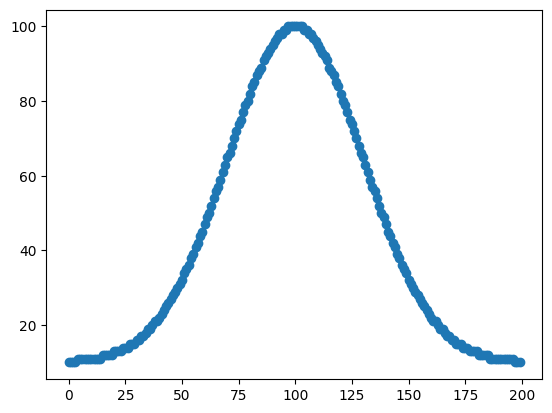

In [ ]:
# Gaussian breathe effect lookup calculation
maxBrightness:float = 100
minBrightness:float = 10
nSamples:int = 200
beta:float = 0.5
gamma:float = .15

LUT:list[float] = [0] * nSamples

def gaussian(index:int, maxB:float, minB:float, nSamples:int, beta:float, gamma:float) -> float:
    brightness:float = 0
    if index < nSamples:
        brightness = minB + (maxB - minB) * exp(-(((index / nSamples) - beta) ** 2 / (2 * gamma**2)))
    return brightness


for i in range(nSamples):
    LUT[i] = gaussian(i, maxBrightness, minBrightness, nSamples, beta, gamma)

# Print as a python "list" with only two decimals
print("[", end="")
for i in LUT[:-1]:
    result = round(i,2)
    print(f"{result:.2f}", end=", ")
print(f"{LUT[-1]:.2f}]")

# Print as C array
print("{", end="")
for i in LUT[:-1]:
    print(f"{round(i * 100,0):.0f}", end=", ")
print(f"{round(LUT[-1] * 100,0):.0f}}}")

plt.scatter(range(nSamples), LUT)

# Data Structures

## Data needed to keep track of the effect

* $T_{pwm}$: period of the PWM wave, set by adjusting the TOP value of the timer, as the frequency of the clock is fixed at 38.4MHz (with a prescaler of 1). It's hardcoded in the FW and I can't see a reason right now to change it dynamically.
* $T_{effect}$: period of the effect. This needs to change dynamically.
* waves per sample: number of PWM cycles per sample of the LUT. Changes with $T_{effect}$. Easy to calculate on the fly, but stored as to not do the same division time and time again.
* $n_{samples}$: number of samples on the breathe effect Lookup Table. No reason to change dynamically, so hardcoded.
* current PWM wave: keep track of the number of PWM waves played for a particular sample.
* LUT index: current sample of the LUT being played.

## Breathe Effect display parameters

These set of parameters define the effect to be played. They are all the parameters required to build the LUT. In principle, they should not need to change dynamically as I expect to find the sweet spot through testing. There's a potential for them to be "dynamic" if blending multiple LED strips together with different curves is pleasant, but that would require a different input method (eg. via BLE) or hard-coding a set of effects.

The Gaussian curve is defined by the max and min brightness, the gamma coefficient (width of the pulse), beta coefficient (relative position of the peak) and the size of the lookup table.

## Breathe Effect Control Parameters

These are the parameters that control the playing of a breathe effect.

To control the playing of a breath effect, we will need to know the period of the effect, the current sample to play from the LUT and a counter for the number of PWM waves played for a certain sample. The number of PWM waves to play per sample can be easily calculated from the period of the effect, the period of the PWM and the number of samples of the LUT, but we can keep it at hand as it will be needed often.

## LED data structure

This is the main data structure for a LED Strip effect. I called it just `LED` for shorts.

Keeps track of the current effect being played on the LED Strip, its current brightness, the period of the PWM signal (can be easily calculated and it's harcoded, so it just could be a `const`, but it's nice to have it accessible) and a pointer to a breatheControl_t structure that contains the control parameters.
